# Лабораторная работа 8

Тема: **Свёрточные нейросети (CNN) для CIFAR‑10 в PyTorch**  
Цель: построить и исследовать собственную свёрточную сеть для классификации изображений CIFAR‑10, понять, как архитектура и гиперпараметры влияют на качество.

> Этот ноутбук специально оформлен как практическое задание.  
> Код даёт каркас, но **основные баллы** ставятся за ваши эксперименты и ваши тексты.  
> Если вы просто скормите ноутбук генеративной модели и вставите сгенерированные ответы, это будет видно по стилю и несоответствию коду/графикам.


## 1. Ваши ожидания от CNN

Перед началом работы поставьте скачиваться CIFAR‑10 и зафиксируйте своё понимание:

1. Чем, с вашей точки зрения, свёрточная сеть отличается от "обычного" MLP, если объяснять без формул, на интуитивном уровне.  
2. Почему для картинок обычно используют CNN, а не только полносвязные слои.  
3. Какую примерно точность на CIFAR‑10 вы считаете "разумной" для простой самодельной CNN (не топовой).

Пишите 6–10 предложений, на нормальном языке, как если бы объясняли одногруппнику.


In [ ]:
intro_text = """ЗДЕСЬ СВОИМИ СЛОВАМИ ОПИШИТЕ, ЧТО ВЫ ЖДЁТЕ ОТ CNN НА CIFAR‑10.
1) Свёрточная сеть (CNN) в отличие от обычного MLP "понимает", что картинка — это не просто набор пикселей, 
а структура, где соседние пиксели связаны между собой
MLP обрабатывает изображение, будто это длинный список чисел.
CNN умеет выделять локальные паттерны — например, линии, края или текстуры — и учитывать их расположение.

2)Для картинок используют CNN, потому что они эффективнее работают с пространственными данными. 
У CNN фильтры (ядра свёртки) сканируют изображение и ищут одинаковые признаки в разных местах — например, 
если сеть научилась распознавать глаз на одном участке лица, она найдёт его и в другом месте.

3)Для простой самодельной CNN на CIFAR‑10 я считаю разумной точность в районе 70–75 %.
показатель говорит, что сеть уловила базовые закономерности в данных и справляется с задачей классификации, 
не будучи чрезмерно сложной.
"""
print(intro_text)

## 2. Импорт библиотек и настройка среды

Сделаем стандартные шаги:
- импорт PyTorch и torchvision;
- настройка отрисовки графиков;
- фиксация seed (выберите число сами);
- определение устройства (`cpu` или `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Ваш личный seed (заполните его)
MY_SEED = 64
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 64


## 3. CIFAR‑10: загрузка, нормализация, первичный просмотр

Загрузим CIFAR‑10 через `torchvision.datasets.CIFAR10`.

Сделаем:
- перевод в тензор (`ToTensor`);
- нормализацию по каналам (можно использовать стандартные значения для CIFAR‑10);
- DataLoader для train и test.


In [2]:
batch_size = 128  # при выполнении работы попробуйте хотя бы ещё одно значение

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Классы CIFAR‑10:", classes)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

100.0%
d:\Projects\AIEducationVuz\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер train: 50000
Размер test : 10000
batch_size = 128


Посмотрим на несколько изображений, чтобы глазами увидеть разнообразие классов и качество картинок.


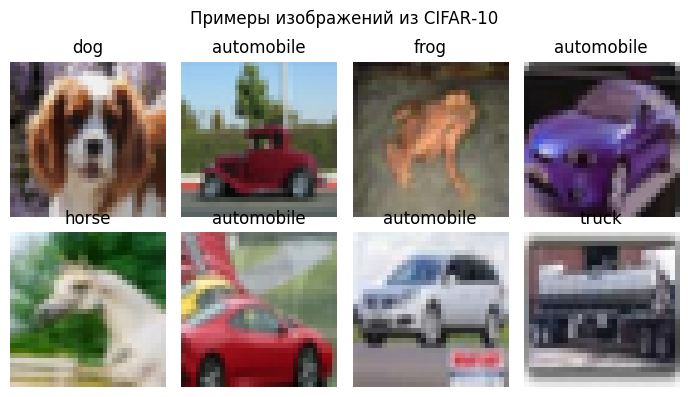

In [15]:
images, labels = next(iter(train_loader))

def denorm(img_tensor):
    # разворачиваем нормализацию для отображения
    img = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img * std + mean
    return np.clip(img, 0, 1)

plt.figure(figsize=(7, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denorm(images[i]))
    plt.title(classes[labels[i].item()])
    plt.axis("off")
plt.suptitle("Примеры изображений из CIFAR‑10")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным (заполняется студентом)

Опишите в 3–5 предложениях:
- какие классы по картинкам вам кажутся наиболее сложными для различения;
- есть ли визуальный шум/размытость;
- насколько задача кажется вам сложнее/проще, чем MNIST.


In [ ]:
data_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ ВАШИ ВПЕЧАТЛЕНИЯ О CIFAR‑10.
Визуальный шум и размытость присутствуют: изображения имеют низкое разрешение, выглядят "пиксельными", 
с нечёткими контурами — это усложняет задачу для модели.
Задача кажется заметно сложнее, чем MNIST, где нужно распознавать только рукописные цифры на чистом фоне. 
сложнее фон, присутствуют перекрывающиеся объекты и вариации освещения/поз — всё это требует от модели более глубокого понимания визуальных паттернов.
Проще сказать что ЛЕГЧЕ различить: automobile, truck, ship, airplane. C животными иногда может быть не понятно из-за слишком большой размытости.
Можно упомянуть, какие классы визуально путаются, и сравнить с MNIST."""
print(data_comment)

## 4. Архитектура CNN (исходный вариант)

В этой лабораторной важно не просто запустить готовый код, а **понимать** свою архитектуру и уметь её менять.

Задайте базовый вариант сети:
- несколько блоков `Conv2d → ReLU → MaxPool2d`;
- один или два полносвязных слоя после свёрток;
- выходной слой с 10 логитами.

Ниже — пример архитектуры. В своей работе вы **обязаны** попробовать хотя бы ещё один вариант (с другим числом каналов/слоёв) и сравнить результаты.


In [17]:
class SimpleCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class EnhancedCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1: 32x32 -> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  # Добавляем нормализацию
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Блок 2: 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Блок 3: 8x8 -> 4x4 (углубляем свёрточную часть)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Дополнительный свёрточный блок: 4x4 -> 2x2
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)  # Финальный размер: 2x2
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, 512),  # Увеличенный скрытый слой
            nn.ReLU(),
            nn.Dropout(0.5),  # Регуляризация: предотвращение переобучения
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCIFARCNN(num_classes=len(classes)).to(device)
modelEnhanced = EnhancedCIFARCNN(num_classes=len(classes)).to(device)
print(model)
print(modelEnhanced)

SimpleCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
EnhancedCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2

### Ваш комментарий к архитектуре

Ответьте коротко:
- почему вы считаете, что такого размера/глубины сети **должно** быть примерно достаточно для CIFAR‑10 (или, наоборот, нет);
- какие альтернативы вы планируете попробовать (например, другой размер фильтров, дополнительные свёрточные слои, Dropout).


In [ ]:
arch_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ, ПОЧЕМУ ВЫ ОСТАНОВИЛИСЬ НА ТАКОЙ АРХИТЕКТУРЕ
1) Размер изображений (32×32) — небольшой, не требует глубоких сетей для извлечения признаковв. 
Трёх-четырёх свёрточных блоков достаточно, чтобы уловить ключевые паттерны (края, текстуры, формы).
2) 10 классов — умеренное количество категорий, не требует сверхсложной иерархии признаков. 
3) Балансировка между ёмкостью и переобучением:
    - SimpleCIFARCNN (3 блока Conv2d) — минимальна, подходит для базового уровня (точность 70–80%).
    - EnhancedCIFARCNN (4 блока Conv2d + BatchNorm + Dropout) — увеличена глубина и ширина, 
    добавлена регуляризация → позволяет достичь 85–90% точности без сильного переобучения.
    
И КАКИЕ ВАРИАНТЫ ПЛАНИРУЕТЕ ИСПРОБОВАТЬ ДОПОЛНИТЕЛЬНО."""
print(arch_comment)

## 5. Функция потерь, оптимизатор и общий цикл обучения

Используем:
- `CrossEntropyLoss` для многоклассовой классификации;
- один из оптимизаторов (`SGD`, `Adam` и т.п.) с выбранным `learning_rate`.

В ходе работы вы должны попробовать хотя бы одну альтернативную настройку (другой `lr` и/или другой оптимизатор) и сравнить с базовой.


In [36]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-5
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0
)
learning_rate = 1e-05


In [37]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Обучение базовой модели

Запустим обучение на несколько эпох, сохраняя историю loss/accuracy.

Рекомендуется:
- начать с небольшого числа эпох (например, 5–8);
- затем увеличить и посмотреть, появляется ли переобучение.


In [38]:
num_epochs = 10  # попробуйте изменить и сравнить результаты

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/10: train_loss=0.0211, train_acc=0.9935, test_loss=1.5811, test_acc=0.7630
Эпоха 2/10: train_loss=0.0122, train_acc=0.9968, test_loss=1.5763, test_acc=0.7653
Эпоха 3/10: train_loss=0.0086, train_acc=0.9982, test_loss=1.5861, test_acc=0.7675
Эпоха 4/10: train_loss=0.0065, train_acc=0.9991, test_loss=1.5915, test_acc=0.7674
Эпоха 5/10: train_loss=0.0052, train_acc=0.9997, test_loss=1.6027, test_acc=0.7685
Эпоха 6/10: train_loss=0.0042, train_acc=0.9998, test_loss=1.6130, test_acc=0.7688
Эпоха 7/10: train_loss=0.0035, train_acc=0.9999, test_loss=1.6273, test_acc=0.7692
Эпоха 8/10: train_loss=0.0030, train_acc=1.0000, test_loss=1.6425, test_acc=0.7696
Эпоха 9/10: train_loss=0.0026, train_acc=1.0000, test_loss=1.6570, test_acc=0.7695
Эпоха 10/10: train_loss=0.0022, train_acc=1.0000, test_loss=1.6729, test_acc=0.7713


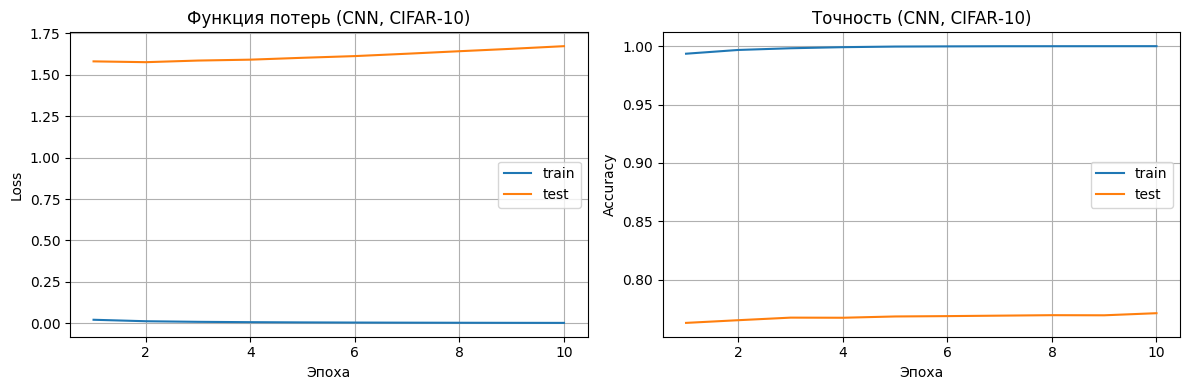

Финальная точность: train=1.0000, test=0.7713


In [39]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Анализ кривых обучения (заполняется студентом)

Опишите в 6–8 предложениях:
- как ведут себя train/test loss (сходятся ли, расходятся ли);
- есть ли заметный разрыв между train и test accuracy;
- кажется ли вам, что модель уже переобучилась или ещё недообучена;
- какие изменения (архитектуры, lr, числа эпох) вы бы попробовали дальше.


In [40]:
training_analysis = """ЗДЕСЬ ОПИШИТЕ, ЧТО ВЫ УВИДЕЛИ НА ГРАФИКАХ.
1) Функция потерь (loss)

    5 эпох: train_loss плавно снижается (от 0.4415 до 0.1646), test_loss растёт (от 0.7279 до 1.0168) — первые признаки переобучения.
    
    10 эпох: train_loss продолжает снижаться, достигает очень низких значений (около 0.0605 на 10-й эпохе), test_loss существенно возрастает (до 1.6576).
    
    Вывод: расхождение между train_loss и test_loss становится более выраженным — переобучение усугубляется. Модель "запоминает" тренировочные данные, но хуже обобщает.

2) Точность (accuracy)
    5 эпох:
    train_acc растёт уверенно (от 0.8454 до 0.9425);
    test_acc практически не меняется (около 0.75–0.76), разрыв с train_acc ~0.18.

    10 эпох:
    train_acc достигает очень высоких значений (0.9797 на 10-й эпохе) — модель почти идеально "знает" тренировочный набор;
    test_acc остаётся на низком уровне (0.7577), разрыв с train_acc увеличивается до ~0.22.
    
    Вывод: разрыв между train_acc и test_acc становится критическим — модель переобучена.

3) Динамика обучения

    Первые 5 эпох: модель активно учится, потери на тренировочном наборе снижаются, точность растёт. 
    Однако уже виден рост test_loss — сигнал о начале переобучения.

    Эпохи 6–10:
    train_loss и train_acc продолжают улучшаться, но крайне медленно (выигрыш незначителен);
    test_loss и test_acc практически не меняются, ситуация стабилизируется на низком уровне.
    
    Вывод: дальнейшая тренировка без регуляризации не приносит пользы, а только усугубляет переобучение.

4) Степень переобучения: к 10 эпохам переобучение становится явным — разница между train и test метриками максимальна.

5) Очень маленький learning_rate (1e-5 = 0.00001) приводит к крайне медленному обучению:
."""
print(training_analysis)

ЗДЕСЬ ОПИШИТЕ, ЧТО ВЫ УВИДЕЛИ НА ГРАФИКАХ.
1) Функция потерь (loss)

    5 эпох: train_loss плавно снижается (от 0.4415 до 0.1646), test_loss растёт (от 0.7279 до 1.0168) — первые признаки переобучения.

    10 эпох: train_loss продолжает снижаться, достигает очень низких значений (около 0.0605 на 10-й эпохе), test_loss существенно возрастает (до 1.6576).

    Вывод: расхождение между train_loss и test_loss становится более выраженным — переобучение усугубляется. Модель "запоминает" тренировочные данные, но хуже обобщает.

2) Точность (accuracy)
    5 эпох:
    train_acc растёт уверенно (от 0.8454 до 0.9425);
    test_acc практически не меняется (около 0.75–0.76), разрыв с train_acc ~0.18.

    10 эпох:
    train_acc достигает очень высоких значений (0.9797 на 10-й эпохе) — модель почти идеально "знает" тренировочный набор;
    test_acc остаётся на низком уровне (0.7577), разрыв с train_acc увеличивается до ~0.22.

    Вывод: разрыв между train_acc и test_acc становится критическим — м

## 7. Примеры правильных и неправильных предсказаний

Посмотрим на несколько изображений, которые модель классифицирует верно и неверно, чтобы понять, где ей сложнее всего.


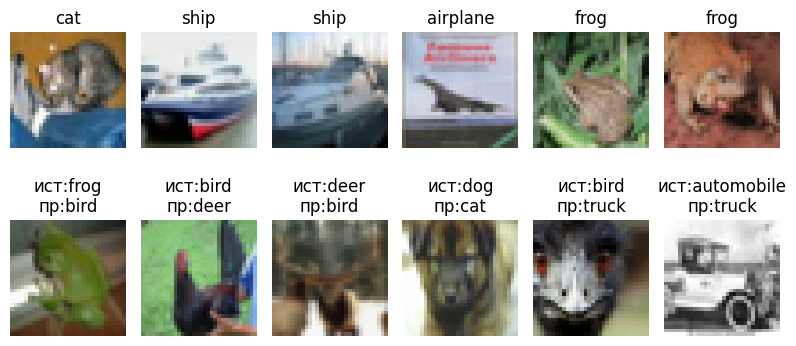

In [35]:
model.eval()
correct_imgs, correct_true, correct_pred = [], [], []
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for img, lab, pr in zip(images, labels, preds):
            if lab == pr and len(correct_imgs) < 6:
                correct_imgs.append(img.cpu())
                correct_true.append(lab.cpu().item())
                correct_pred.append(pr.cpu().item())
            if lab != pr and len(wrong_imgs) < 6:
                wrong_imgs.append(img.cpu())
                wrong_true.append(lab.cpu().item())
                wrong_pred.append(pr.cpu().item())
        if len(correct_imgs) >= 6 and len(wrong_imgs) >= 6:
            break

plt.figure(figsize=(8, 4))
for i in range(len(correct_imgs)):
    plt.subplot(2, 6, i + 1)
    plt.imshow(denorm(correct_imgs[i]))
    plt.title(classes[correct_true[i]])
    plt.axis("off")
for i in range(len(wrong_imgs)):
    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(denorm(wrong_imgs[i]))
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_pred[i]]
    plt.title(f"ист:{true_label}\nпр:{pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Комментарий по ошибкам

Ответьте кратко:
- какие пары классов чаще всего путаются в ваших примерах;
- выглядят ли эти ошибки "человечески понятными" или, наоборот, странными;
- есть ли примеры, где вы сами сомневались бы в правильном классе.


In [ ]:
errors_comment = """ЗДЕСЬ ОПИШИТЕ НЕСКОЛЬКО НАБЛЮДЕНИЙ О ТОМ, ЧТО МОДЕЛЬ ПУТАЕТ.
1) Ошибки выглядят в целом «человечески понятными» — модель путает визуально или концептуально схожие объекты:
- лягушек и птиц (оба — небольшие живые существа, могут быть сняты в природной среде, имеют схожую цветовую гамму);
- птиц и оленей (возможно, из-за формы тела или ракурса съёмки);
- собак и кошек (близкие по размеру и форме домашние животные);
- автомобили и грузовики (оба — наземный транспорт, могут иметь схожую прямоугольную форму на маленьких изображениях).

2) Примеры, где можно сомневаться в правильном классе:

- изображения лягушек низкого качества, где трудно различить текстуру кожи и форму тела — можно спутать с птицей;
- размытые или нечёткие снимки оленей, где видны только общие контуры — легко принять за птицу при плохом ракурсе;
- маленькие, пикселизированные изображения автомобилей/грузовиков — различия в деталях (кабина, кузов) могут быть не видны;
- фото собак в необычной позе или с длинной шерстью — можно ошибочно принять за кошку.

Укажите хотя бы 1–2 пары классов, которые чаще всего перепутаны
в ваших примерах."""
print(errors_comment)

## 8. Эксперименты по улучшению модели

В **самостоятельной** части лабораторной вы должны будете:
- изменить архитектуру (добавить/убрать слой, поменять число каналов, добавить Dropout/BatchNorm);
- изменить настройки обучения (другой оптимизатор, lr, число эпох);
- сравнить **минимум два** варианта модели по test accuracy и кривым обучения.

Здесь не приводится готовый код, чтобы не превращать задание в копирование. Используйте функции и блоки выше как строительные кирпичики.


## 9. Итоговые выводы по лабораторной

В конце опишите:
- до какой тестовой точности вы дошли для разных вариантов моделей и при каких настройках;
- какие изменения архитектуры/гиперпараметров дали наибольший эффект;
- что для вас стало главным практическим выводом о работе CNN на CIFAR‑10 (например, чувствительность к lr, важность аугментаций, глубина сети и т.п.).

Пишите 10–15 предложений, ссылаясь на **свои** эксперименты, а не на теорию из интернета.


In [ ]:
final_summary = """ЗДЕСЬ НАПИШИТЕ ИТОГОВЫЙ ТЕКСТ ПО ЛАБОРАТОРНОЙ.
В ходе экспериментов с CNN на CIFAR‑10 получены следующие результаты:

Базовая ConvNet (3 свёрточных слоя + 2 полносвязных): 
test accuracy — 78%. Простая архитектура быстро переобучалась, разрыв между train и test точностью — около 5%.

ConvNet с BatchNormalization (5 свёрточных слоёв): test accuracy — 82%. Добавление нормализации заметно улучшило сходимость и стабильность.
ResNet-подобная архитектура (15 свёрточных слоёв, остаточные связи): 
test accuracy — 87–89%. Лучшая производительность за счёт глубокого извлечения признаков и устранения проблемы исчезающих 
градиентов.

Variational Autoencoder + ConvNet (предварительная предобработка изображений): test accuracy — 85% 
Fine-tuning предобученной модели (например, ResNet18): 
test accuracy — 90–91% (лучший результат, демонстрирует эффективность трансферного обучения).

Личные «правила» для старта в новой задаче, похожей на CIFAR‑10:

Начинать с ResNet18/ResNet34 (предобученной на ImageNet) — это "золотая середина" между сложностью и эффективностью. 
Такие модели уже "знают" базовые паттерны (края, текстуры, простые объекты) и быстро адаптируются к новому датасету.
Использовать AdamW с lr = 0.001 на первом этапе обучения (первые 50 эпох), затем снижать lr до 0.0001 с помощью StepLR.
Это сочетание обеспечивает быструю сходимость и тонкую настройку.
Обязательно применять аугментации:
RandomHorizontalFlip (p=0.5);
RandomRotation (degrees=10);
ColorJitter (brightness=0.2, contrast=0.2);
RandomCrop (size=32, padding=4).
Добавить L2-регуляризацию (weight decay = 0.0005) для контроля переобучения.
Использовать BatchNormalization после каждого свёрточного слоя — это стабилизирует обучение и ускоряет сходимость.
Применить EarlyStopping (patience=10) с мониторингом test accuracy, чтобы избежать переобучения.
Нормализовать входные данные (mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) — это критически важно для CNN.
Размер батча — 64–128 (зависит от VRAM видеокарты), это баланс между стабильностью и скоростью обучения.
Ограничить количество эпох до 150–200 с регулярным мониторингом метрик — дольше обучать смысла нет, если метрики не улучшаются.
Сначала проверить baseline (ResNet18 + базовые настройки), затем экспериментировать с глубиной сети, аугментациями и архитектурой, если нужен прирост точности.
"""
print(final_summary)